In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1, n_redundant=0, n_classes=2,
                           n_clusters_per_class=1, random_state=41, hypercube=False, class_sep=15)

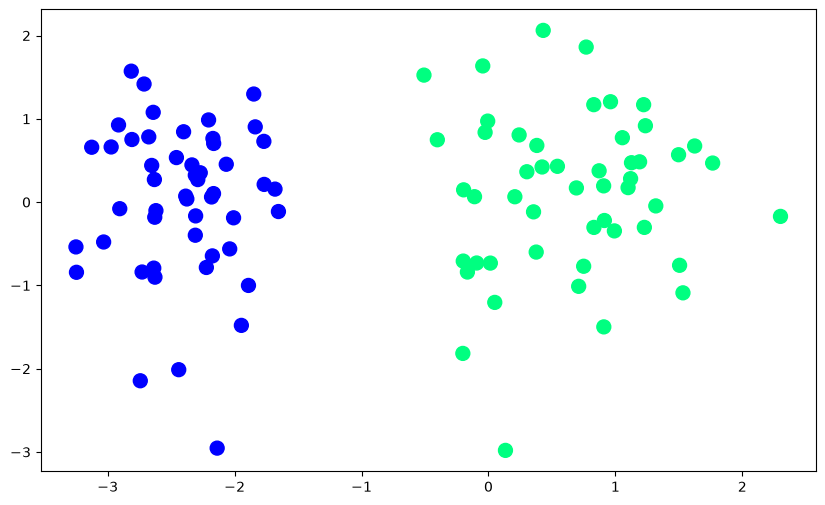

In [3]:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100)

### Using Step function:

In [4]:
def step(z):
    return 1 if z > 0 else 0

In [5]:
def perceptron(X, y):
	X = np.insert(X, 0, 1, axis=1)
	weights = np.ones(X.shape[1])
	lr = 0.1
	
	for i in range(1000):
		j = np.random.randint(0, X.shape[0])
		y_pred = step(np.dot(X[j], weights))
		weights = weights + lr * (y[j] - y_pred) * X[j]

	return weights[0], weights[1:]

In [6]:
intercept_, coef_ = perceptron(X, y)

In [7]:
print(f"Intercept: {intercept_}")
print(f"Coefficients: {coef_}")

Intercept: 1.2000000000000002
Coefficients: [1.15679783 0.24825228]


In [8]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [9]:
X_input = np.linspace(-3, 3, 100)
y_input = m * X_input + b

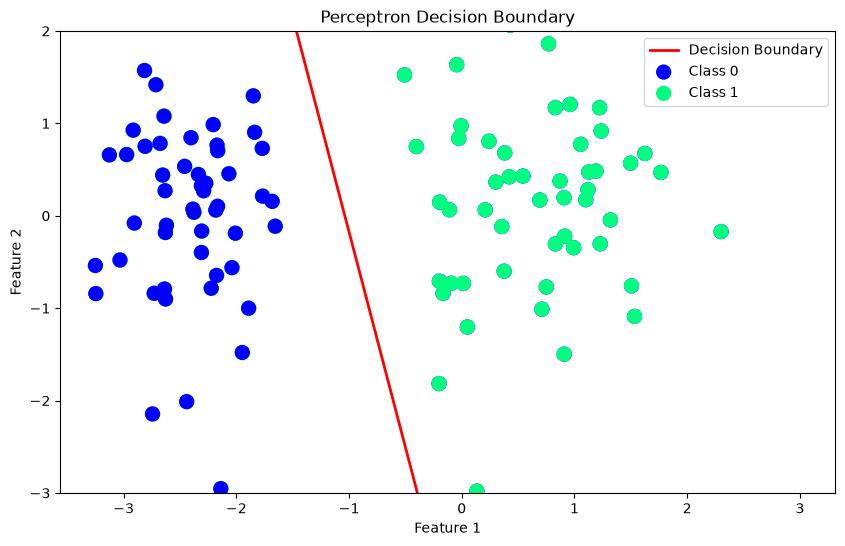

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(X_input, y_input, color='red', label='Decision Boundary', linewidth=2)
plt.scatter(X[:, 0], X[:, 1], c = 1-y, cmap='winter', s=100, label='Class 0')
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100, label='Class 1')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.legend()

### Using Sigmoid function:

In [11]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [12]:
def perceptron(X, y):
	X = np.insert(X, 0, 1, axis=1)
	weights = np.ones(X.shape[1])
	lr = 0.1
	
	for i in range(1000):
		j = np.random.randint(0, X.shape[0])
		y_pred = sigmoid(np.dot(X[j], weights))
		weights = weights + lr * (y[j] - y_pred) * X[j]

	return weights[0], weights[1:]

In [13]:
intercept_, coef_ = perceptron(X, y)

In [14]:
print(f"Intercept: {intercept_}")
print(f"Coefficients: {coef_}")

Intercept: 2.8967865502638386
Coefficients: [3.47230468 0.00835486]


In [15]:
m = -(coef_[0] / coef_[1])
b = -(intercept_ / coef_[1])

In [16]:
X_input1 = np.linspace(-3, 3, 100)
y_input1 = m * X_input1 + b

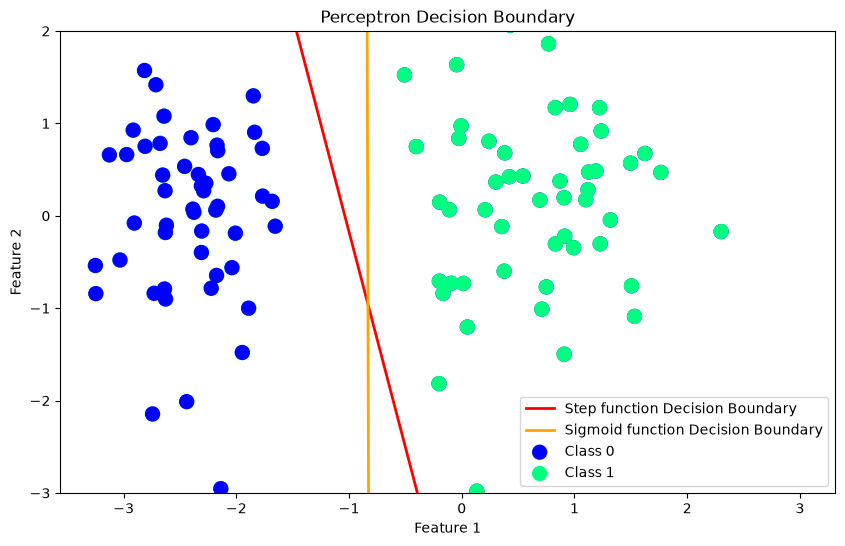

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(X_input, y_input, color='red', label='Step function Decision Boundary', linewidth=2)
plt.plot(X_input1, y_input1, color='orange', label='Sigmoid function Decision Boundary', linewidth=2)
plt.scatter(X[:, 0], X[:, 1], c = 1-y, cmap='winter', s=100, label='Class 0')
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100, label='Class 1')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Perceptron Decision Boundary')
plt.legend()

### Using SKLearn Logistic Regression:

In [18]:
lor = LogisticRegression()
lor.fit(X, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [19]:
print(f"Intercept: {lor.intercept_}")
print(f"Coefficients: {lor.coef_}")

Intercept: [2.83692515]
Coefficients: [[2.87172972 0.03069442]]


In [20]:
m_new = -(lor.coef_[0][0] / lor.coef_[0][1])
b_new = -(lor.intercept_ / lor.coef_[0][1])

In [21]:
X_input2 = np.linspace(-3, 3, 100)
y_input2 = m_new * X_input2 + b_new

### Comparing the 3 different approaches:

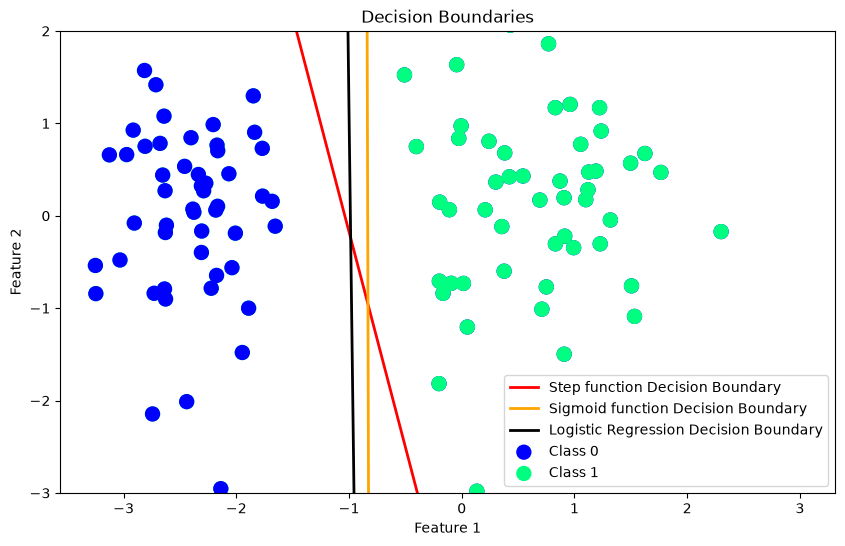

In [22]:
plt.figure(figsize=(10, 6))
plt.plot(X_input, y_input, color='red', label='Step function Decision Boundary', linewidth=2)
plt.plot(X_input1, y_input1, color='orange', label='Sigmoid function Decision Boundary', linewidth=2)
plt.plot(X_input2, y_input2, color='black', label='Logistic Regression Decision Boundary', linewidth=2)
plt.scatter(X[:, 0], X[:, 1], c = 1-y, cmap='winter', s=100, label='Class 0')
plt.scatter(X[:, 0], X[:, 1], c = y, cmap='winter', s=100, label='Class 1')
plt.ylim(-3, 2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundaries')
plt.legend()

### Why the Sigmoid Perceptron Still Isn't Optimal:

Swapping the step function for sigmoid fixes one problem — the update rule now uses a smooth, continuous error signal (`y - sigmoid(z)`) instead of a hard 0/1 jump, so the decision boundary is no longer forced into an arbitrary "any separating line will do" solution. But it still doesn't converge to the same optimal boundary as sklearn's `LogisticRegression`, for a few structural reasons:

1. **No real cost function is being minimized.** The perceptron update rule (`weights + lr * (y - y_pred) * X`) is a heuristic borrowed from the original Step-function Perceptron — it was never derived from minimizing Log Loss. Plugging in sigmoid changes the *shape* of the update, but it isn't actually gradient descent on the binary cross-entropy cost function logistic regression is built around. sklearn's `LogisticRegression` explicitly minimizes Log Loss (with L2 regularization by default), which is what guarantees convergence toward the boundary that best separates the classes probabilistically.

2. **Single random sample per update, fixed learning rate, fixed iteration count.** This implementation updates weights using one randomly picked sample per step (closer to plain SGD) for a fixed 1000 iterations with `lr=0.1`. There's no convergence check, no learning rate decay, and no guarantee 1000 steps is enough — sklearn's solver iterates until the optimization actually converges (or a much larger max iteration limit is hit), using more sophisticated optimizers (`lbfgs` by default) rather than basic SGD.

3. **No regularization.** sklearn's `LogisticRegression` applies L2 regularization by default, which shapes the final boundary slightly differently than an unregularized fit would.

4. **Weight initialization and randomness.** Weights start at `np.ones(...)` here rather than zero or a principled initialization, and since only one random sample updates the weights per step, results can vary run to run — sklearn's solver is deterministic given the same data (up to solver tolerance).

In short: using sigmoid instead of a step function makes the perceptron *behave* more like logistic regression (smooth probabilities, more sensible boundary), but it's still not *equivalent* to logistic regression — it's an approximation using the wrong optimization target and a much cruder optimizer.